# Upscaling de Conductividad Hidráulica — ¿Qué media usar?

**Contexto:** Al refinar o engrossar una malla de modelación numérica,
los valores de $K$ deben escalarse. La pregunta clave es: **¿cuál media
representa mejor el comportamiento hidráulico equivalente?**

| Dirección de flujo | Media correcta | Fórmula |
|---|---|---|
| Horizontal (paralelo a capas) | **Aritmética** | $K_A = \frac{1}{n}\sum K_i$ |
| Vertical (serie, perpendicular) | **Armónica** | $K_H = \frac{n}{\sum 1/K_i}$ |
| Isótropo 2D aleatorio | **Geométrica** | $K_G = \left(\prod K_i\right)^{1/n}$ |

> *Matheron (1967) demostró que para un medio isótropo 2D con K lognormal,
> $K_{\text{eff}} = K_G$ exactamente.*


In [1]:
import os, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)
print(f"Working dir: {ROOT}")


Working dir: /home/abelardo/UNAM/1.-Optimization_Course


## Parámetros de entrada

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ── PARÁMETROS AJUSTABLES ─────────────────────────────────────────────────
GRID_SIZE = 3          # tamaño de la malla fina (3 → upscale 3x3 a 1x1)
SEED      = 42         # reproducibilidad
np.random.seed(SEED)

# Generar campo K aleatorio lognormal (m/s)
mu_Y    = np.log(1e-4)   # media de ln(K)
sigma_Y = 1.0             # variabilidad
K_fine  = np.random.lognormal(mean=mu_Y, sigma=sigma_Y, size=(GRID_SIZE, GRID_SIZE))

print(f"Malla fina:   {GRID_SIZE}x{GRID_SIZE}  →  Malla gruesa: 1x1")
print(f"Valores K [m/s]:")
for row in K_fine:
    print("  " + "   ".join(f"{v:.2e}" for v in row))


Malla fina:   3x3  →  Malla gruesa: 1x1
Valores K [m/s]:
  1.64e-04   8.71e-05   1.91e-04
  4.59e-04   7.91e-05   7.91e-05
  4.85e-04   2.15e-04   6.25e-05


## Cálculo de las tres medias

In [3]:
def media_aritmetica(K):
    return np.mean(K)

def media_geometrica(K):
    return np.exp(np.mean(np.log(K)))

def media_armonica(K):
    return 1.0 / np.mean(1.0 / K)

K_vals = K_fine.ravel()

Ka = media_aritmetica(K_vals)
Kg = media_geometrica(K_vals)
Kh = media_armonica(K_vals)

print(f"{'Estimador':<25} {'Valor [m/s]':>14}  {'log10(K)':>10}")
print("-" * 54)
print(f"{'K_A  (aritmética)':<25} {Ka:>14.3e}  {np.log10(Ka):>10.2f}")
print(f"{'K_G  (geométrica)  ← 2D':<25} {Kg:>14.3e}  {np.log10(Kg):>10.2f}")
print(f"{'K_H  (armónica)':<25} {Kh:>14.3e}  {np.log10(Kh):>10.2f}")
print("-" * 54)
print(f"  Siempre:  K_H <= K_G <= K_A")
print(f"  Verifica: {Kh:.2e} <= {Kg:.2e} <= {Ka:.2e}  →  {Kh<=Kg<=Ka}")


Estimador                    Valor [m/s]    log10(K)
------------------------------------------------------
K_A  (aritmética)              2.025e-04       -3.69
K_G  (geométrica)  ← 2D        1.549e-04       -3.81
K_H  (armónica)                1.234e-04       -3.91
------------------------------------------------------
  Siempre:  K_H <= K_G <= K_A
  Verifica: 1.23e-04 <= 1.55e-04 <= 2.02e-04  →  True


## Visualización: malla fina → malla gruesa

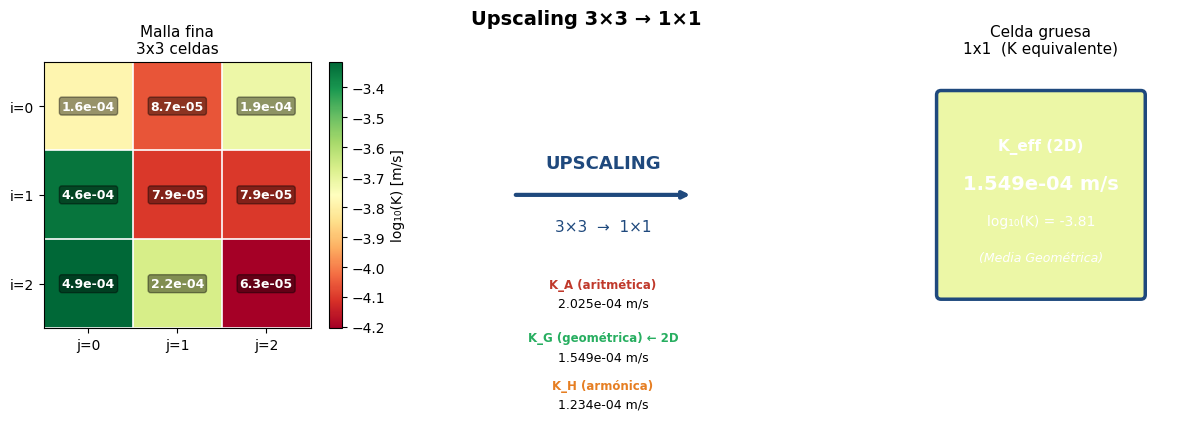

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle(f"Upscaling {GRID_SIZE}×{GRID_SIZE} → 1×1", fontsize=14, fontweight='bold')

AZUL  = '#1F497D'
VERDE = '#27AE60'
ROJO  = '#C0392B'

# ── Panel izquierdo: malla fina ──────────────────────────────────
ax = axes[0]
im = ax.imshow(np.log10(K_fine), cmap='RdYlGn', aspect='equal')
plt.colorbar(im, ax=ax, label='log₁₀(K) [m/s]', fraction=0.046)

# Etiquetas en cada celda
for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        ax.text(j, i, f"{K_fine[i,j]:.1e}", ha='center', va='center',
                fontsize=9, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.4))

# Líneas de celda
for k in range(GRID_SIZE + 1):
    ax.axhline(k - 0.5, color='white', lw=1.2)
    ax.axvline(k - 0.5, color='white', lw=1.2)

ax.set_title(f"Malla fina\n{GRID_SIZE}x{GRID_SIZE} celdas", fontsize=11)
ax.set_xticks(range(GRID_SIZE)); ax.set_yticks(range(GRID_SIZE))
ax.set_xticklabels([f'j={j}' for j in range(GRID_SIZE)])
ax.set_yticklabels([f'i={i}' for i in range(GRID_SIZE)])

# ── Panel central: flecha de upscaling ──────────────────────────
ax2 = axes[1]
ax2.axis('off')
ax2.annotate('', xy=(0.75, 0.5), xytext=(0.25, 0.5),
             xycoords='axes fraction', textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', lw=3, color=AZUL))
ax2.text(0.5, 0.62, 'UPSCALING', ha='center', va='center',
         transform=ax2.transAxes, fontsize=13, fontweight='bold', color=AZUL)
ax2.text(0.5, 0.38, f'{GRID_SIZE}×{GRID_SIZE}  →  1×1', ha='center', va='center',
         transform=ax2.transAxes, fontsize=11, color=AZUL)

# Tabla de resultados
tabla_y = 0.15
for val, lbl, col in [(Ka,'K_A (aritmética)',ROJO),
                       (Kg,'K_G (geométrica) ← 2D',VERDE),
                       (Kh,'K_H (armónica)',   '#E67E22')]:
    ax2.text(0.5, tabla_y, f'{lbl}', ha='center', fontsize=8.5,
             transform=ax2.transAxes, color=col, fontweight='bold')
    ax2.text(0.5, tabla_y - 0.07, f'{val:.3e} m/s', ha='center', fontsize=9,
             transform=ax2.transAxes, color='black')
    tabla_y -= 0.2 if lbl.startswith('K_A') else 0.18

# ── Panel derecho: celda upscaleada ─────────────────────────────
ax3 = axes[2]
ax3.set_xlim(-0.1, 1.1); ax3.set_ylim(-0.1, 1.1)
ax3.set_aspect('equal')
ax3.axis('off')

rect = patches.FancyBboxPatch((0.05, 0.05), 0.9, 0.9,
                               boxstyle="round,pad=0.02",
                               linewidth=2.5, edgecolor=AZUL,
                               facecolor=plt.cm.RdYlGn(0.55))
ax3.add_patch(rect)

ax3.text(0.5, 0.72, 'K_eff (2D)', ha='center', va='center',
         fontsize=11, color='white', fontweight='bold')
ax3.text(0.5, 0.55, f'{Kg:.3e} m/s', ha='center', va='center',
         fontsize=14, color='white', fontweight='bold')
ax3.text(0.5, 0.38, f'log₁₀(K) = {np.log10(Kg):.2f}', ha='center', va='center',
         fontsize=10, color='white')
ax3.text(0.5, 0.22, '(Media Geométrica)', ha='center', va='center',
         fontsize=9, color='white', style='italic')
ax3.set_title("Celda gruesa\n1x1  (K equivalente)", fontsize=11)

plt.tight_layout()
plt.savefig('docs/unidad_01/notas/upscaling_demo.png', dpi=150, bbox_inches='tight')
plt.show()


## ¿Cambia el resultado con el tamaño de malla?

In [5]:
# Prueba con distintos tamaños de malla fina → mismo K_eff grueso
np.random.seed(SEED)
tamanios = [2, 3, 4, 5, 7, 10]
resultados = []

for n in tamanios:
    K = np.random.lognormal(mean=mu_Y, sigma=sigma_Y, size=(n, n)).ravel()
    resultados.append({
        'Tamaño': f'{n}x{n}',
        'n_celdas': n*n,
        'K_A': media_aritmetica(K),
        'K_G': media_geometrica(K),
        'K_H': media_armonica(K),
    })

print(f"{'Malla fina':<12} {'n celdas':>8}  {'K_A [m/s]':>12}  {'K_G [m/s]':>12}  {'K_H [m/s]':>12}")
print("-" * 62)
for r in resultados:
    print(f"{r['Tamaño']:<12} {r['n_celdas']:>8}  {r['K_A']:>12.3e}  {r['K_G']:>12.3e}  {r['K_H']:>12.3e}")

print()
print("Nota: K_G converge al valor teórico exp(mu_Y) =", f"{np.exp(mu_Y):.3e}", "m/s")
print("      conforme n aumenta (ley de grandes números en escala log).")


Malla fina   n celdas     K_A [m/s]     K_G [m/s]     K_H [m/s]
--------------------------------------------------------------
2x2                 4     2.253e-04     1.882e-04     1.601e-04
3x3                 9     1.496e-04     1.151e-04     9.630e-05
4x4                16     8.582e-05     5.646e-05     4.095e-05
5x5                25     1.182e-04     7.851e-05     5.324e-05
7x7                49     1.387e-04     9.765e-05     6.226e-05
10x10             100     1.730e-04     1.066e-04     7.153e-05

Nota: K_G converge al valor teórico exp(mu_Y) = 1.000e-04 m/s
      conforme n aumenta (ley de grandes números en escala log).


## Conclusión

Para **upscaling 2D isótropo** (malla fina → malla gruesa), la media correcta es la **geométrica**:

$$K_{\text{eff}} = K_G = \exp\!\left(\frac{1}{n}\sum_{i=1}^n \ln K_i\right)$$

- Válida para medios heterogéneos isótropos con $K$ lognormal (Matheron, 1967).
- Siempre acotada: $K_H \leq K_G \leq K_A$.
- Converge al valor teórico $e^{\mu_Y}$ al aumentar el número de celdas.

**Referencia:** Matheron, G. (1967). *Éléments pour une théorie des milieux poreux.* Masson, Paris.
